In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, KernelPCA
import umap

# Set plot style
sns.set_theme(style="whitegrid")

# 1. Load the data
print("Loading data...")
# Assuming the first column contains the TCGA sample IDs
df = pd.read_csv('../data/processed/methylation_lihc_pd_all.csv', index_col=0)



/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...


In [ ]:
# 2. Preprocessing: Handle missing values
# Methylation arrays almost always have NaNs (e.g., due to low bead count). 
# Dimensionality reduction algorithms cannot handle NaNs.
print("Imputing missing values...")
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df)

# Note: We typically don't apply StandardScaler to methylation beta values 
# because they are already bounded between 0 and 1, but you can if you prefer.

# 3. Apply Dimensionality Reduction Techniques

# --- PCA ---
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)



Imputing missing values...
Running PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

In [3]:
# --- Kernel PCA ---
# Using an RBF (Radial Basis Function) kernel. 
print("Running Kernel PCA...")
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=False, n_jobs=-1)
X_kpca = kpca.fit_transform(X)



Running Kernel PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [4]:
# --- UMAP ---
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X)



Running UMAP...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting results...


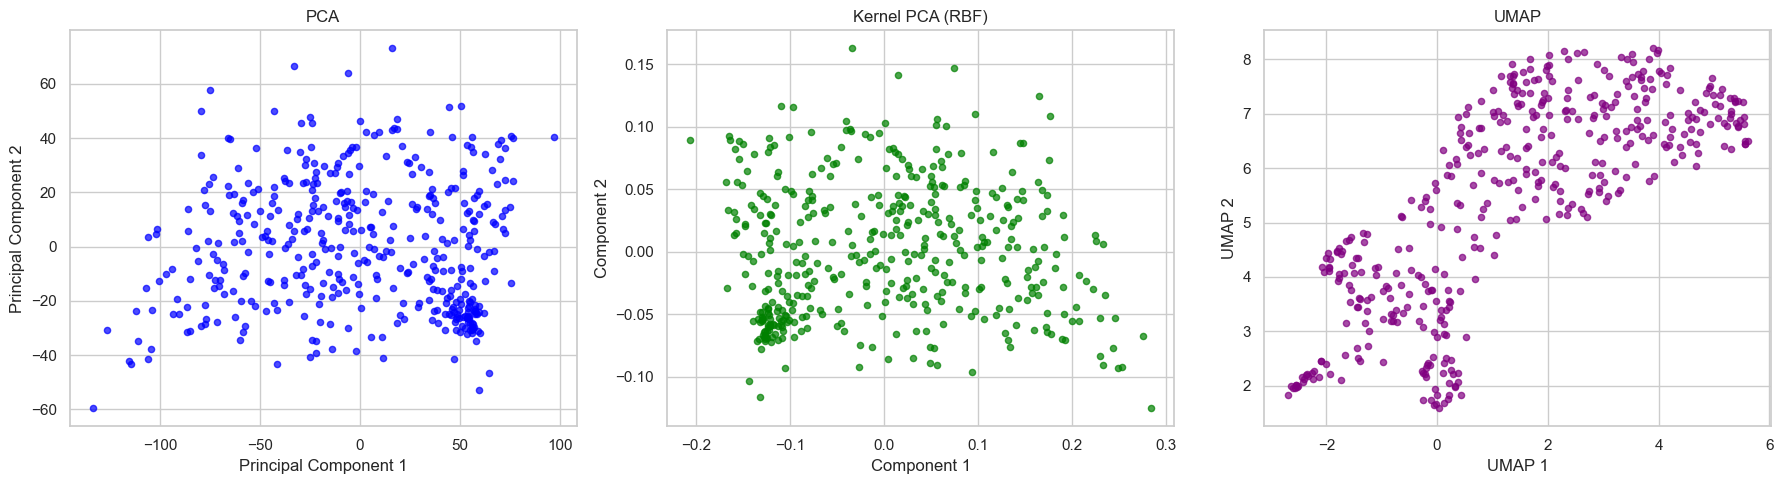

In [5]:
# 4. Visualization
print("Plotting results...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=20, c='blue')
axes[0].set_title('PCA')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Plot Kernel PCA
axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], alpha=0.7, s=20, c='green')
axes[1].set_title('Kernel PCA (RBF)')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

# Plot UMAP
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7, s=20, c='purple')
axes[2].set_title('UMAP')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

In [6]:


# 1. Load the data
print("Loading data...")
# Assuming the first column contains the TCGA sample IDs
df = pd.read_csv('../data/processed/methylation_lihc_pd_tumor.csv', index_col=0)



Loading data...


In [7]:
# 2. Preprocessing: Handle missing values
# Methylation arrays almost always have NaNs (e.g., due to low bead count). 
# Dimensionality reduction algorithms cannot handle NaNs.
print("Imputing missing values...")
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df)

# Note: We typically don't apply StandardScaler to methylation beta values 
# because they are already bounded between 0 and 1, but you can if you prefer.

# 3. Apply Dimensionality Reduction Techniques

# --- PCA ---
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)



Imputing missing values...
Running PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

In [8]:
# --- Kernel PCA ---
# Using an RBF (Radial Basis Function) kernel. 
print("Running Kernel PCA...")
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=False, n_jobs=-1)
X_kpca = kpca.fit_transform(X)



Running Kernel PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
# --- UMAP ---
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X)



Running UMAP...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting results...


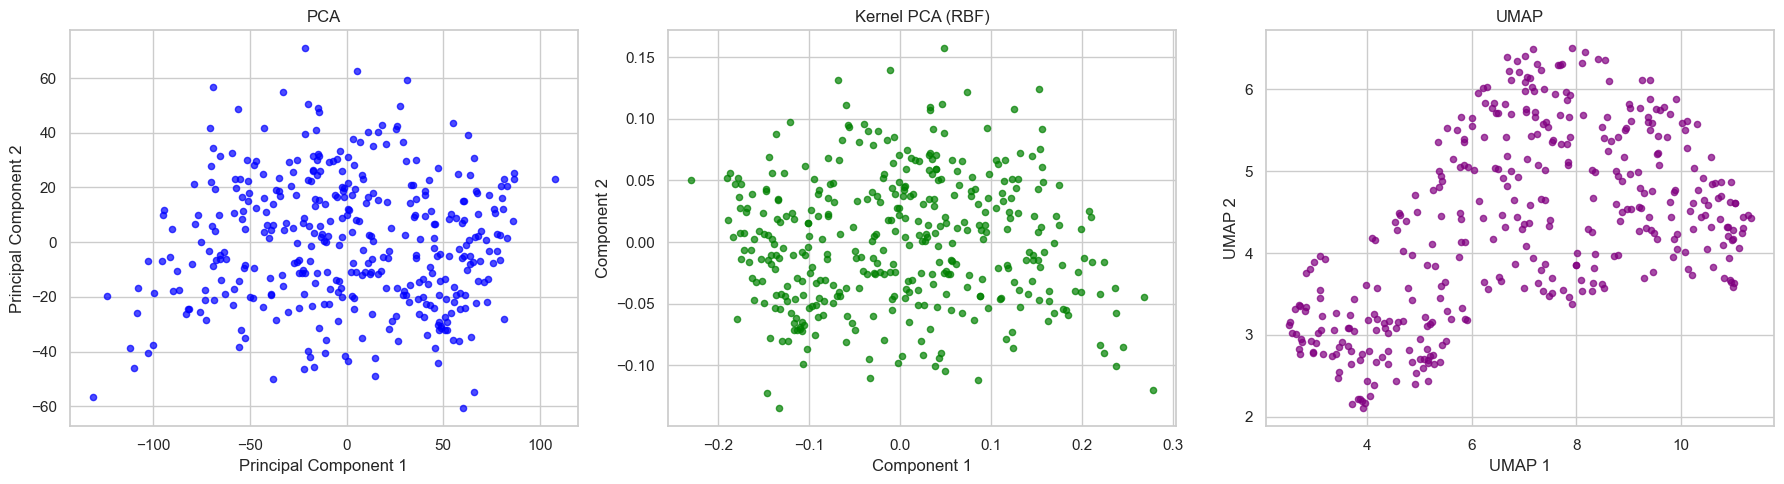

In [10]:
# 4. Visualization
print("Plotting results...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=20, c='blue')
axes[0].set_title('PCA')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Plot Kernel PCA
axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], alpha=0.7, s=20, c='green')
axes[1].set_title('Kernel PCA (RBF)')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

# Plot UMAP
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7, s=20, c='purple')
axes[2].set_title('UMAP')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()